In [2]:
import pandas as pd
import glob
import numpy as np 
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

In [4]:
#Marge data from each month into one CSV

files = glob.glob('C:/Users/pujab/Downloads/Sales_Analysis_Pandas/Sales_Data/*.csv')

df = pd.concat((pd.read_csv(file) for file in files), ignore_index = True)

df.shape

(186850, 6)

In [753]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [754]:
df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,355,21903,168552,21903,355,355


In [755]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


In [ ]:
#Cleane up data

In [756]:
df.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [757]:
df.dropna(inplace = True)

In [758]:
df.duplicated().sum()

np.int64(618)

In [759]:
df.drop_duplicates(inplace = True)

In [760]:
df.shape

(185687, 6)

In [761]:
#Add Month Column

In [762]:
df['Month'] = df['Order Date'].str[0:2]
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",04
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",04
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",04
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",04


In [763]:
df.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
Month               object
dtype: object

In [ ]:
#Make columns correct type

In [764]:
for col in ['Order ID', 'Quantity Ordered', 'Price Each', 'Month']:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

In [765]:
df.dtypes

Order ID            float64
Product              object
Quantity Ordered    float64
Price Each          float64
Order Date           object
Purchase Address     object
Month               float64
dtype: object

In [766]:
df.isnull().sum()

Order ID            1
Product             0
Quantity Ordered    1
Price Each          1
Order Date          0
Purchase Address    0
Month               1
dtype: int64

In [767]:
df.dropna(inplace=True)

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558.0,USB-C Charging Cable,2.0,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4.0
2,176559.0,Bose SoundSport Headphones,1.0,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4.0
3,176560.0,Google Phone,1.0,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4.0
4,176560.0,Wired Headphones,1.0,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4.0
5,176561.0,Wired Headphones,1.0,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4.0


In [768]:
for col in ['Order ID', 'Quantity Ordered', 'Month']:
    df[col] = df[col].astype(int)

df.head() 

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4


In [ ]:
#Add total sales column

In [769]:
df['Total Sales'] = df['Price Each'] * df['Quantity Ordered']

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Total Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99


In [770]:
#Add a city column

In [771]:
def get_city(address):
    return address.split(',')[1]

def get_state(address):
    return address.split(',')[2].split(' ')[1]

df['City'] = df['Purchase Address'].apply(lambda x: f"{get_city(x)} ({get_state(x)})")
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Total Sales,City
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas (TX)
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston (MA)
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles (CA)
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA)
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA)


In [772]:
#### Q.1:What was the best month for sales?How much was earned that month?

In [773]:
monhtly_sale = df.groupby('Month')[['Total Sales']].sum()
monhtly_sale

,Total Sales
Month,
1,1821413.16
2,2200078.08
3,2804973.35
4,3389217.98
5,3150616.23
6,2576280.15
7,2646461.32
8,2241083.37
9,2094465.69


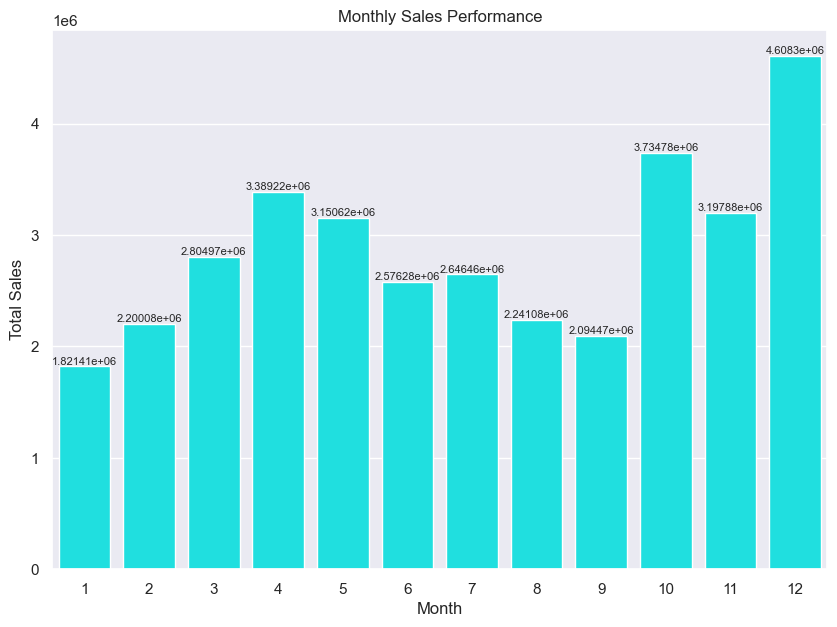

In [774]:
ax = sns.barplot(x = 'Month', y = 'Total Sales', data = monhtly_sale, color = 'cyan')
plt.title('Monthly Sales Performance')
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)

In [775]:
####Q.2:What city had the highest number of sales?

In [776]:
city_sales = df.groupby('City')[['Total Sales']].sum().sort_values(by='Total Sales', ascending=False)
city_sales

,Total Sales
City,
San Francisco (CA),8254743.55
Los Angeles (CA),5448304.28
New York City (NY),4661867.14
Boston (MA),3658627.65
Atlanta (GA),2794199.07
Dallas (TX),2765373.96
Seattle (WA),2745046.02
Portland (OR),1870010.56
Austin (TX),1818044.33


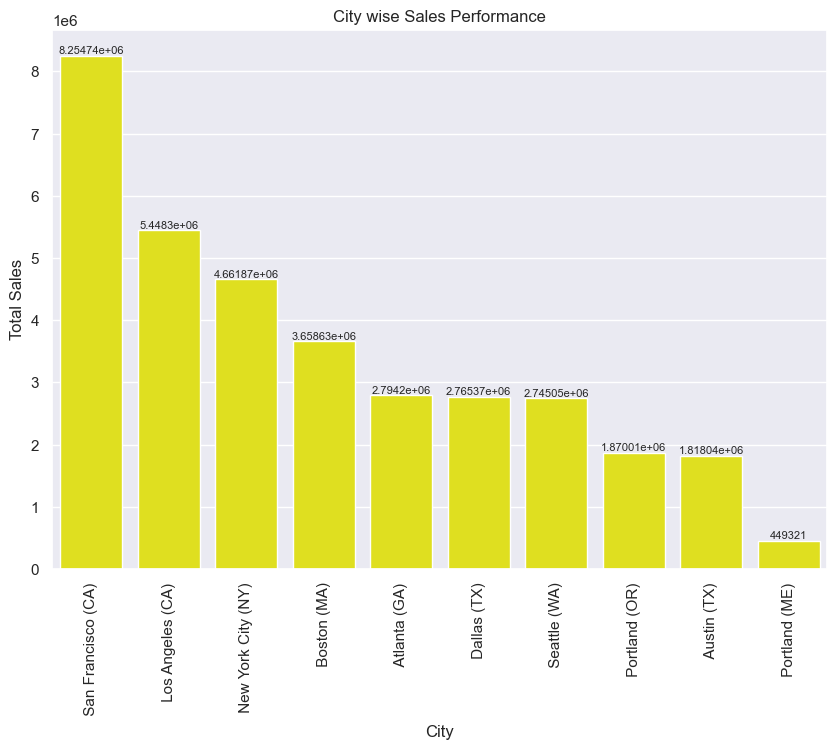

In [777]:
ax = sns.barplot(x = 'City', y = 'Total Sales', data = city_sales, color = 'yellow')
plt.title('City wise Sales Performance')
plt.xticks(rotation='vertical')
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)

In [778]:
####Q.3:What tume should we display advertisements to maximaze likelihood of customer's buying product?

In [ ]:
#Change data type of 'Order Date'

In [779]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

C:\Users\pujab\AppData\Local\Temp\ipykernel_25168\3072535395.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


In [ ]:
#Add Hour column

In [780]:
df['Hour'] = df['Order Date'].dt.hour
df['Minute'] = df['Order Date'].dt.minute

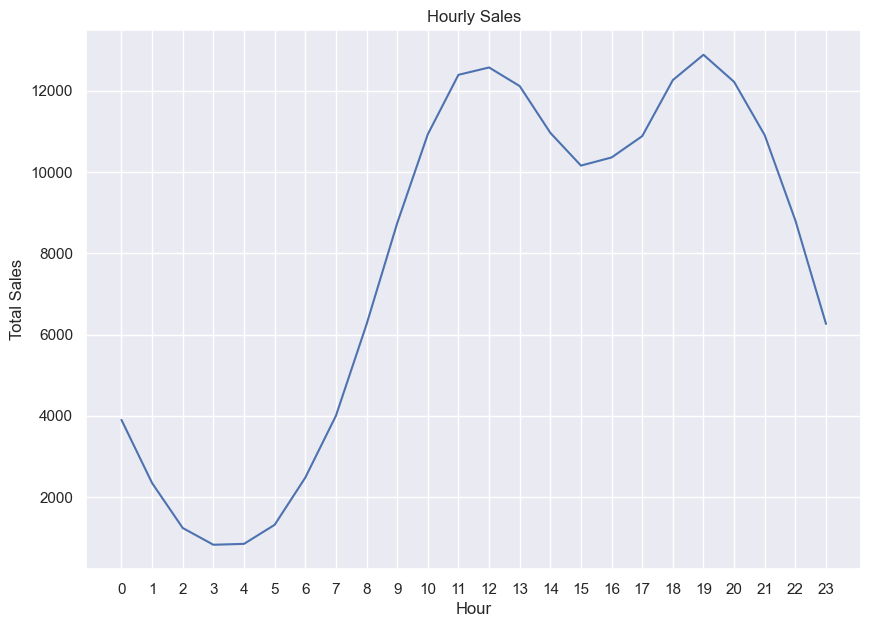

In [781]:
hourly_sales = df.groupby('Hour')[['Total Sales']].count()
ax = sns.lineplot(x = 'Hour', y = 'Total Sales', data = hourly_sales)
plt.title('Hourly Sales')
plt.xticks(range(24))
fig.tight_layout()

# My recommendation is slightly before 11am or 7pm

In [782]:
####Q.4:What products are most often sold together?

In [783]:
from itertools import combinations
from collections import Counter

#only keep orders with more than 1 product
df2 = df.groupby('Order ID')['Product'].apply(list)

#create pairs
pairs = []
for products in df2:
    pairs.extend(combinations(products,2))

#count most common pairs
pair_counts = Counter(pairs)

for key, value in pair_counts.most_common(10):
    print(key, value)

('iPhone', 'Lightning Charging Cable') 1002
('Google Phone', 'USB-C Charging Cable') 985
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 413
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 159
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92


In [794]:
####Q.5:What product sold the most?Why do you think it sold the most?

In [785]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Total Sales,City,Hour,Minute
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas (TX),8,46
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston (MA),22,30
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles (CA),14,38
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),14,38
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),9,27


In [786]:
product_sold = df.groupby('Product')[['Quantity Ordered']].sum()
product_sold

,Quantity Ordered
Product,
20in Monitor,4126
27in 4K Gaming Monitor,6239
27in FHD Monitor,7541
34in Ultrawide Monitor,6192
AA Batteries (4-pack),27615
AAA Batteries (4-pack),30986
Apple Airpods Headphones,15637
Bose SoundSport Headphones,13430
Flatscreen TV,4813


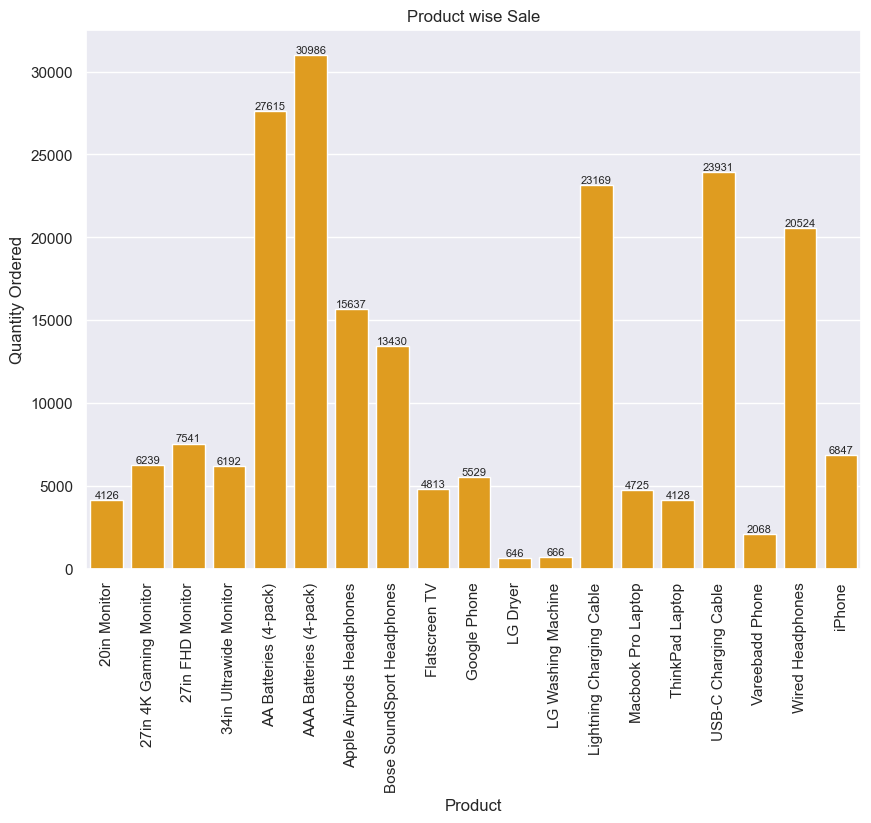

In [790]:
ax = sns.barplot(x = 'Product', y = 'Quantity Ordered', data = product_sold, color = 'orange')
plt.title('Product wise Sale')
plt.xticks(rotation='vertical')
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)

In [788]:
prices = df.groupby('Product')[['Price Each']].mean()
prices

,Price Each
Product,
20in Monitor,109.99
27in 4K Gaming Monitor,389.99
27in FHD Monitor,149.99
34in Ultrawide Monitor,379.99
AA Batteries (4-pack),3.84
AAA Batteries (4-pack),2.99
Apple Airpods Headphones,150.00
Bose SoundSport Headphones,99.99
Flatscreen TV,300.00


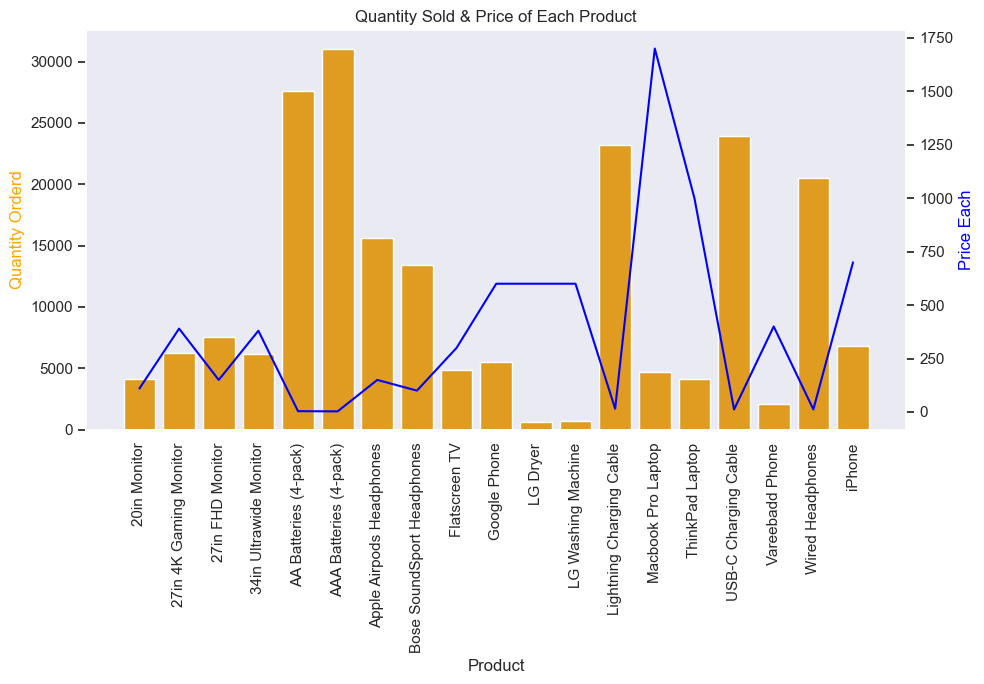

In [792]:
fig, ax1 = plt.subplots()

sns.barplot(x = 'Product', y = 'Quantity Ordered', data = product_sold, color = 'orange', ax = ax1)
ax1.set_ylabel('Quantity Orderd', color = 'orange')
ax1.grid(False)

ax2 = ax1.twinx()
sns.lineplot(x = 'Product', y = 'Price Each', data = prices, color = 'blue', ax = ax2)
ax2.set_ylabel('Price Each', color = 'blue')
ax2.grid(False)

plt.title('Quantity Sold & Price of Each Product')
ax1.tick_params(axis = 'x', rotation = 90)
fig.tight_layout()